# 1. MODULE IMPORT & SETUP

In [3]:
# Data Handling and Utilities
import pandas as pd
import numpy as np
import re
import time
import string

# Machine Learning Models
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

# Feature Engineering
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import TfidfTransformer

# Evaluation Metrics and Visualization
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc,roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Natural Language Processing (NLP) Tools
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Hugging Face
from transformers import pipeline
from sklearn.pipeline import Pipeline

# NLTK Downloads and Initialization
nltk.download('punkt_tab')
nltk.download('stopwords')
stop_words = stopwords.words('english')
nltk.download('wordnet')
lemmatizer = WordNetLemmatizer()

# Define a global random state for reproducibility
RANDOM_STATE = 42

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# 2. DATA LOADING & STRUCTURAL PREPROCESSING

In [4]:
# Reading Dataset
df = pd.read_csv('drive/MyDrive/stat project/Reviews.csv') #Jaswanth's Drive
#df = pd.read_csv('/content/drive/MyDrive/CSC1181 Foundations of Statistical Analysis & Machine Learning/Project/Reviews.csv') #henry's review's location
#df = pd.read_csv('/content/sample_data/Reviews.csv')

Print First Five records (Initial EDA)

In [5]:
df.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


# 3.EDA

In [6]:
print("Dataset Description (Numeric Columns):")
print(df.describe())
print("-" * 30)

Dataset Description (Numeric Columns):
                  Id  HelpfulnessNumerator  HelpfulnessDenominator  \
count  568454.000000         568454.000000            568454.00000   
mean   284227.500000              1.743817                 2.22881   
std    164098.679298              7.636513                 8.28974   
min         1.000000              0.000000                 0.00000   
25%    142114.250000              0.000000                 0.00000   
50%    284227.500000              0.000000                 1.00000   
75%    426340.750000              2.000000                 2.00000   
max    568454.000000            866.000000               923.00000   

               Score          Time  
count  568454.000000  5.684540e+05  
mean        4.183199  1.296257e+09  
std         1.310436  4.804331e+07  
min         1.000000  9.393408e+08  
25%         4.000000  1.271290e+09  
50%         5.000000  1.311120e+09  
75%         5.000000  1.332720e+09  
max         5.000000  1.351210e+09

In [7]:
df.columns

Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [8]:
df.info() #Gives info about datset. (Dtype and count of non-nulls)
df.isnull().sum() #Gives count of null values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


,0
Id,0
ProductId,0
UserId,0
ProfileName,26
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,27
Text,0


In [9]:
df['Score'].value_counts()

,count
Score,
5,363122
4,80655
1,52268
3,42640
2,29769


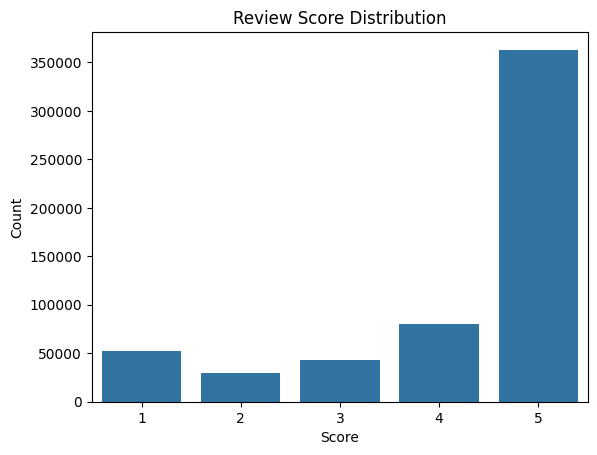

In [10]:
# Plot the distribution of review scores
sns.countplot(x='Score', data=df)
plt.title('Review Score Distribution')
plt.xlabel('Score')
plt.ylabel('Count')
plt.show()

Calculating Helpfulness Ratio

In [11]:
# Helpfulness Ratio is a metric that shows how useful a review was to other users.
# It is calculated as:
#     HelpfulnessRatio = HelpfulnessNumerator / HelpfulnessDenominator

# Where:
# - HelpfulnessNumerator: Number of users who found the review helpful
# - HelpfulnessDenominator: Total number of users who rated the review (helpful or not)


# Example:
# -------------------------------
# If a review has:
#     HelpfulnessNumerator = 3
#     HelpfulnessDenominator = 5
# Then:
#     HelpfulnessRatio = 3 / 5 = 0.6
# This means 60% of users found the review helpful.


# Special Cases:
# -------------------------------
# If HelpfulnessDenominator = 0, the ratio is undefined (division by zero).
# In practice, we usually set it to 0 or treat it as missing.


# Why It Matters:
# -------------------------------
# - Helps identify trustworthy reviews
# - Can be used to filter out low-quality or spammy reviews
# - Useful for analyzing how helpfulness correlates with score, review length, or sentiment

/tmp/ipython-input-887842440.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['HelpfulnessRatio'].fillna(0, inplace=True)


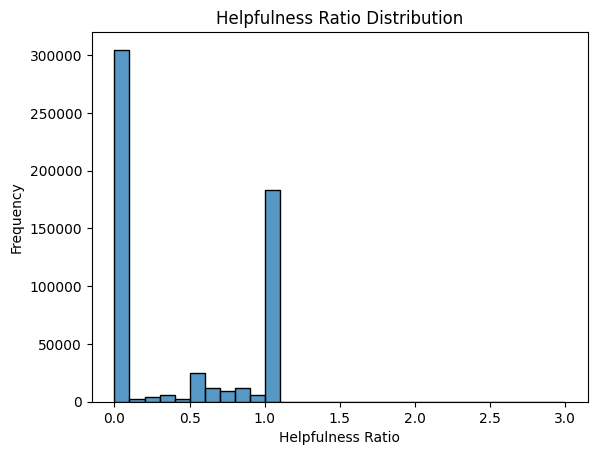

In [12]:
# Create a new column for helpfulness ratio (numerator/denominator)
df['HelpfulnessRatio'] = df['HelpfulnessNumerator'] / df['HelpfulnessDenominator']

# Replace NaN values (from division by zero) with 0
df['HelpfulnessRatio'].fillna(0, inplace=True)

# Plot the distribution of helpfulness ratio
sns.histplot(df['HelpfulnessRatio'], bins=30)
plt.title('Helpfulness Ratio Distribution')
plt.xlabel('Helpfulness Ratio')
plt.ylabel('Frequency')
plt.show()

In [13]:
# Observations: Helpfulness Ratio Histogram
# --------------------------------------------

# 1. Sharp Peak at Helpfulness Ratio = 1.0
# - Most reviews have a ratio of 1.0, meaning all users who rated them found them helpful.
# - This suggests many reviews are perceived as fully useful or trustworthy.

# 2. Ratios Greater Than 1.0 Exist
# - Some reviews show a ratio > 1.0, which is mathematically incorrect.
# - This indicates data quality issues — possibly due to incorrect entries where numerator > denominator.

# 3. Long Tail Below 1.0
# - Many reviews have ratios less than 1.0, meaning not all users found them helpful.
# - These could be vague, subjective, or low-quality reviews.

# 4. Zero or Near-Zero Values
# - Reviews with a ratio of 0 either received no helpful votes or had a denominator of zero.
# - These were handled by filling NaN values with 0 using:
#     df['HelpfulnessRatio'].fillna(0, inplace=True)


# (Optional)
# --------------------------------------------
# - Clean the data: Remove rows where HelpfulnessNumerator > HelpfulnessDenominator
# - Analyze correlation between HelpfulnessRatio and Score
# - Filter reviews with ratio ≥ 0.5 for quality-focused insights

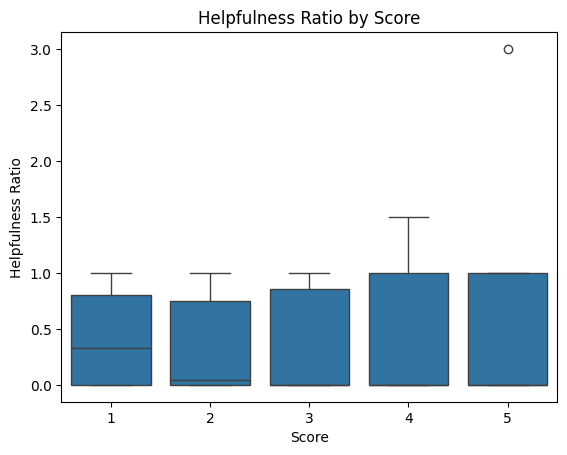

In [14]:
# Boxplot to show helpfulness ratio across different scores
sns.boxplot(x='Score', y='HelpfulnessRatio', data=df)
plt.title('Helpfulness Ratio by Score')
plt.xlabel('Score')
plt.ylabel('Helpfulness Ratio')
plt.show()

Time Based Analysis

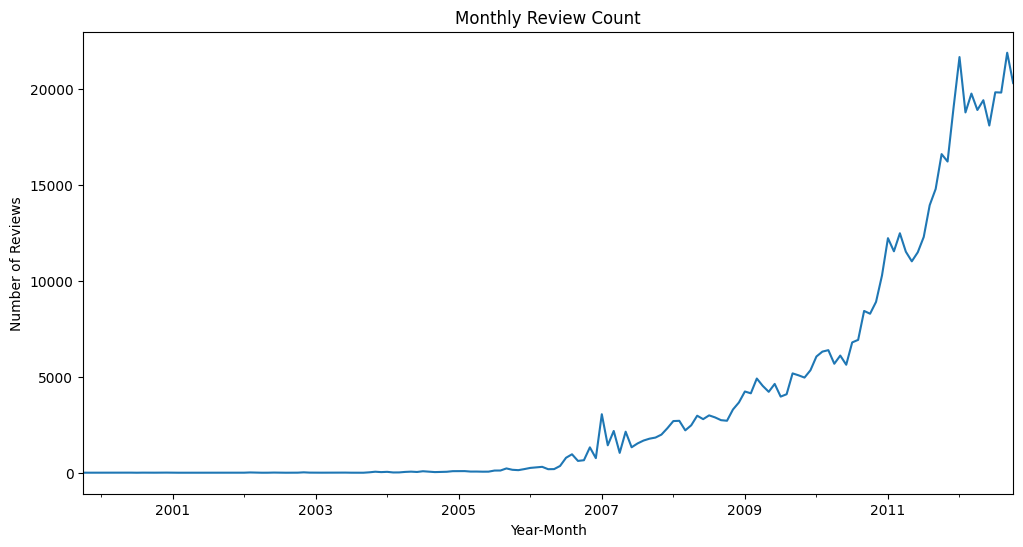

In [15]:
# Convert Unix timestamp to readable datetime format
df['Time'] = pd.to_datetime(df['Time'], unit='s')

# Create a new column for Year-Month to group by time
df['YearMonth'] = df['Time'].dt.to_period('M')

# Count number of reviews per month
monthly_reviews = df.groupby('YearMonth').size()

# Plot review counts over time
monthly_reviews.plot(figsize=(12, 6), title='Monthly Review Count')
plt.ylabel('Number of Reviews')
plt.xlabel('Year-Month')
plt.show()

Textual Analysis

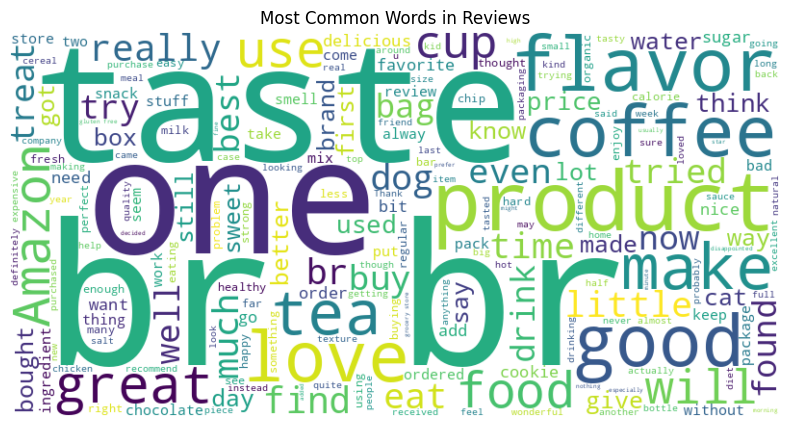

In [16]:
from wordcloud import WordCloud

# Combine a sample of review texts into one string
text = ' '.join(df['Text'].dropna().sample(10000))

# Generate a word cloud from the combined text
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)

# Display the word cloud
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Most Common Words in Reviews')
plt.show()

In [17]:
# Observations: Word Cloud of Review Texts
# --------------------------------------------

# 1. Dominant Themes
# - Words like "taste", "flavor", "coffee", "drink", and "sweet" are prominently featured.
# - This indicates that many reviews focus on sensory experiences and product quality.

# 2. Positive Sentiment Indicators
# - Frequent use of words such as "good", "great", "love", and "treat" suggests a generally positive tone in many reviews.
# - These words are often associated with satisfaction and enjoyment.

# 3. Common Product References
# - Words like "product", "price", "bag", "box", and "cup" appear frequently.
# - This shows that reviewers often mention packaging, value, and product format.

# 4. Presence of Noise
# - The word "br" appears prominently, which is likely an HTML tag or formatting artifact.
# - This suggests that some preprocessing (e.g., HTML cleanup) may be needed to improve text quality.



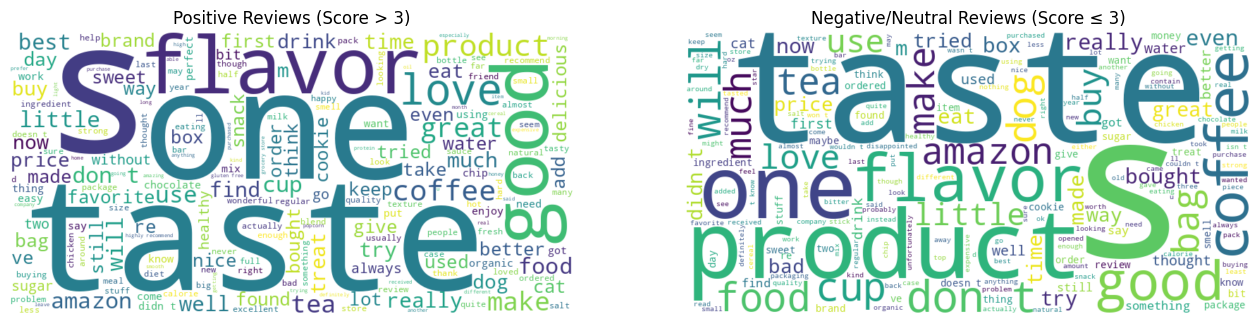

In [18]:
# --------------------------------------------
# Filter reviews by score
# --------------------------------------------
# Positive reviews: Score > 3
positive_reviews = df[df['Score'] > 3]['Text'].dropna()

# Negative/Neutral reviews: Score <= 3
negative_reviews = df[df['Score'] <= 3]['Text'].dropna()

# --------------------------------------------
# Sample 5000 reviews from each group for performance
# --------------------------------------------
positive_sample = positive_reviews.sample(5000, random_state=42)
negative_sample = negative_reviews.sample(5000, random_state=42)

# --------------------------------------------
# Combine and clean text for each group
# --------------------------------------------
from bs4 import BeautifulSoup
import re

def clean_text(text):
    # Remove HTML tags
    text = BeautifulSoup(text, "html.parser").get_text()
    # Remove non-alphabetic characters and convert to lowercase
    text = re.sub('[^A-Za-z]+', ' ', text).lower()
    return text

# Apply cleaning and combine into one string
positive_text = ' '.join(positive_sample.apply(clean_text))
negative_text = ' '.join(negative_sample.apply(clean_text))

# --------------------------------------------
# Generate word clouds
# --------------------------------------------
from wordcloud import WordCloud
import matplotlib.pyplot as plt

positive_wc = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
negative_wc = WordCloud(width=800, height=400, background_color='white').generate(negative_text)

# --------------------------------------------
# Display both word clouds side by side
# --------------------------------------------
plt.figure(figsize=(16, 8))

# Positive reviews
plt.subplot(1, 2, 1)
plt.imshow(positive_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Positive Reviews (Score > 3)')

# Negative/Neutral reviews
plt.subplot(1, 2, 2)
plt.imshow(negative_wc, interpolation='bilinear')
plt.axis('off')
plt.title('Negative/Neutral Reviews (Score ≤ 3)')

plt.show()

In [19]:
print(" Null Values Count:")
print(df.isnull().sum())
print("-" * 30)
initial_rows = len(df)

 Null Values Count:
Id                         0
ProductId                  0
UserId                     0
ProfileName               26
HelpfulnessNumerator       0
HelpfulnessDenominator     0
Score                      0
Time                       0
Summary                   27
Text                       0
HelpfulnessRatio           0
YearMonth                  0
dtype: int64
------------------------------


In [20]:
df.drop_duplicates(inplace=True)
print(f" Exact duplicates across ALL columns removed. Rows remaining: {len(df)}")
print("-" * 30)

 Exact duplicates across ALL columns removed. Rows remaining: 568454
------------------------------


Sort the dataset by 'Time'

In [21]:
df.sort_values(by='Time', inplace=True)
print("Dataset sorted by 'Time' column.")
print("-" * 30)

Dataset sorted by 'Time' column.
------------------------------


Remove duplicate reviews based on UserId and ProductId, keeping the first one

In [22]:
removed = df.drop_duplicates(subset=['UserId', 'ProductId'], keep='first', inplace=True)
print(f"Duplicate UserId/ProductId combinations removed (keeping the latest). Rows remaining: {len(df)}")
print("-" * 30)

Duplicate UserId/ProductId combinations removed (keeping the latest). Rows remaining: 560804
------------------------------


In [23]:
final_rows = len(df)
print(f"Total rows removed during structural cleaning: {initial_rows - final_rows}")
print("-" * 30)

Total rows removed during structural cleaning: 7650
------------------------------


Target Variable Engineering (Sentiment)

binary target: 1 (Positive) for score > 3, 0 (Negative) for score < 3

In [24]:
#Adding new column
df['Sentiment'] = df['Score'].apply(lambda x: 1 if x > 3 else 0)

# 4.Feature Extraction

In [25]:
# Text Preprocessing Function
def preprocess(sen):
  # 1. Lowercasing the sentence
  sen = sen.lower()

  # 2. Word Tokenization
  # We use simple splitting here, as TfidfVectorizer handles final tokenization
  words = nltk.word_tokenize(sen)

  # 3. Stopword Removal
  filtered_words = [word for word in words if word not in stop_words]

  # 4. Remove punctuation
  clean_tokens = [word for word in filtered_words if word not in string.punctuation]

  # 5. join the clean words and return
  return ' '.join(clean_tokens)

In [26]:
df['cleaned_reviews'] = [preprocess(text) for text in df['Text']]

In [27]:
df['cleaned_reviews']

,cleaned_reviews
150523,witty little book makes son laugh loud recite ...
150500,remember seeing show aired television years ag...
451855,beetlejuice well written movie ..... everythin...
230284,twist rumplestiskin captured film starring mic...
451877,twist rumplestiskin captured film starring mic...
...,...
477559,reason giving 4 stars instead 5 stars strange ...
143110,pleased quality espresso pods sturdy enough wi...
110116,love major indian cooking fan -- enough really...
468445,enjoy drinking greek yogurt smoothie morning u...


In [28]:
# Initialize TfidfVectorizer
vectorizer = TfidfVectorizer()

# Fit the Vectorizer
tfidf_matrix = vectorizer.fit_transform(df['cleaned_reviews'])
print(tfidf_matrix.shape)

(560804, 120070)


# Test Train Split

In [29]:
Xtrain_tfidf, Xtest_tfidf, Ytrain, Ytest = train_test_split(tfidf_matrix, df['Sentiment'], test_size=0.2, random_state=42)

# MODEL 1: LOGISTIC REGRESSION

In [30]:
logreg_model = LogisticRegression(C=1.0, solver='liblinear', random_state=RANDOM_STATE)

start_time = time.time()
# Train the model on the training features and targets
logreg_model.fit(Xtrain_tfidf, Ytrain)
end_time = time.time()

In [31]:
print(f"Training Time: {end_time - start_time:.2f} seconds")
print("Training Complete. Model is ready for evaluation.")

Training Time: 16.71 seconds
Training Complete. Model is ready for evaluation.


In [32]:
Ypred = logreg_model.predict(Xtest_tfidf)

# Regression Model Evaluation

Logistic Regression AUC: 0.9416

--- Model Evaluation (on Test Set) ---
Overall Accuracy: 0.8993

Classification Report (Key Metrics for Sentiment):
              precision    recall  f1-score   support

Negative (0)       0.83      0.69      0.75     24662
Positive (1)       0.92      0.96      0.94     87499

    accuracy                           0.90    112161
   macro avg       0.87      0.82      0.84    112161
weighted avg       0.90      0.90      0.90    112161

confusion:
 [[16954  7708]
 [ 3589 83910]] 



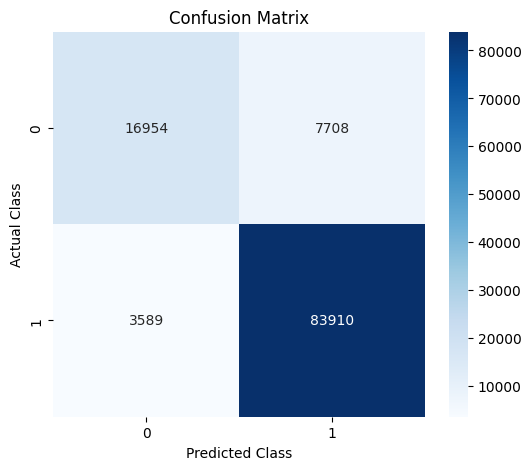

In [33]:
lr_proba = logreg_model.predict_proba(Xtest_tfidf)[:, 1]
lr_auc = roc_auc_score(Ytest, lr_proba)
print(f"Logistic Regression AUC: {lr_auc:.4f}")

print("\n--- Model Evaluation (on Test Set) ---")

# A. Accuracy Score
accuracy = accuracy_score(Ytest, Ypred)
print(f"Overall Accuracy: {accuracy:.4f}")

# B. Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report (Key Metrics for Sentiment):")
# We use target names to clearly label the 0 and 1 classes
print(classification_report(Ytest, Ypred, target_names=['Negative (0)', 'Positive (1)']))

# C. Confusion Matrix (Essential Visualization)
cm = confusion_matrix(Ytest, Ypred)
print("confusion:\n", cm, "\n")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

# MODEL 2: MULTINOMIAL NAIVE BAYES

In [34]:
Xtrain_tfidfnb, Xtest_tfidfnb, Ytrainnb, Ytestnb = train_test_split(tfidf_matrix, df['Sentiment'], test_size=0.2, random_state=42)

In [35]:
nb = MultinomialNB()
nb_start_time = time.time()
nb.fit(Xtrain_tfidfnb, Ytrainnb)
nb_end_time=time.time()
nb_pred = nb.predict(Xtest_tfidfnb)

print(f"Training Time: {nb_end_time - nb_start_time:.2f} seconds")

Training Time: 0.20 seconds


# NaiveBayes Model Evaluation

Naive Bayes Accuracy: 0.8218721302413495
AUC Score: 0.9101

--- Model Evaluation (on Test Set) ---
Overall Accuracy: 0.8219

Classification Report (Key Metrics for Sentiment):
              precision    recall  f1-score   support

Negative (0)       0.91      0.21      0.34     24662
Positive (1)       0.82      0.99      0.90     87499

    accuracy                           0.82    112161
   macro avg       0.86      0.60      0.62    112161
weighted avg       0.84      0.82      0.78    112161

confusion:
 [[ 5198 19464]
 [  515 86984]] 



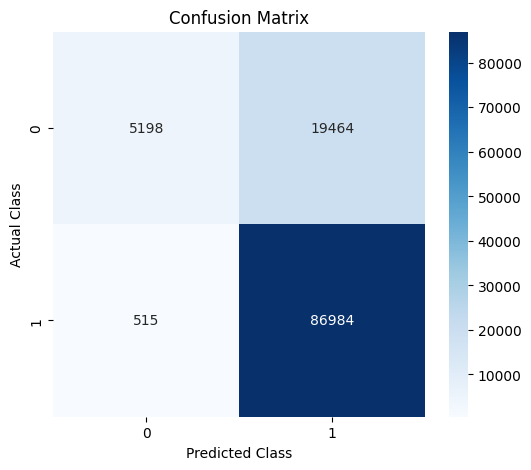

In [36]:
nb_acc = accuracy_score(Ytest, nb_pred)
print("Naive Bayes Accuracy:", nb_acc)
nb_proba = nb.predict_proba(Xtest_tfidf)[:, 1]
nb_auc = roc_auc_score(Ytest, nb_proba)
print(f"AUC Score: {nb_auc:.4f}")
print("\n--- Model Evaluation (on Test Set) ---")

# A. Accuracy Score
accuracy = accuracy_score(Ytest, nb_pred)
print(f"Overall Accuracy: {accuracy:.4f}")

# B. Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report (Key Metrics for Sentiment):")
# We use target names to clearly label the 0 and 1 classes
print(classification_report(Ytest, nb_pred, target_names=['Negative (0)', 'Positive (1)']))

# C. Confusion Matrix (Essential Visualization)
cm = confusion_matrix(Ytest, nb_pred)
print("confusion:\n", cm, "\n")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()


# MODEL 3: HUGGING FACE TRANSFORMERS

In [37]:
# Initialize the sentiment analysis pipeline with a powerful pre-trained model
# 'distilbert/distilbert-base-uncased-finetuned-sst-2-english' is a good choice for general sentiment

classification_pipeline = pipeline(task="sentiment-analysis", model="distilbert/distilbert-base-uncased-finetuned-sst-2-english")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

Device set to use cuda:0


In [38]:
reviews = df['Text']

In [39]:
true_labels = df['Sentiment'].apply(lambda x: 'POSITIVE' if x > 0 else 'NEGATIVE')

In [40]:
true_labels

,Sentiment
150523,POSITIVE
150500,POSITIVE
451855,POSITIVE
230284,POSITIVE
451877,POSITIVE
...,...
477559,POSITIVE
143110,POSITIVE
110116,POSITIVE
468445,POSITIVE


In [41]:
# The pipeline returns a list of dictionaries [{'label': 'LABEL', 'score': 0.99}]

nb_start_time = time.time()
results = [classification_pipeline(text, truncation=True, max_length=512) for text in reviews]
nb_end_time=time.time()
print(f"Training Time: {nb_end_time - nb_start_time:.2f} seconds")

You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


Training Time: 3436.69 seconds


In [42]:
# Extract predicted labels
pred =[result[0] for result in results]
pred =[res['label'] for res in pred]

In [44]:
pred_values = [1 if x == 'POSITIVE' else 0 for x in pred]

# Huggingface transformers Metrics

Overall Accuracy: 0.8344
AUC Score: 0.8311

Classification Report (Key Metrics for Sentiment):
              precision    recall  f1-score   support

Negative (0)       0.59      0.83      0.69    123055
Positive (1)       0.94      0.84      0.89    437749

    accuracy                           0.83    560804
   macro avg       0.77      0.83      0.79    560804
weighted avg       0.87      0.83      0.84    560804

confusion:
 [[101568  21487]
 [ 71410 366339]] 



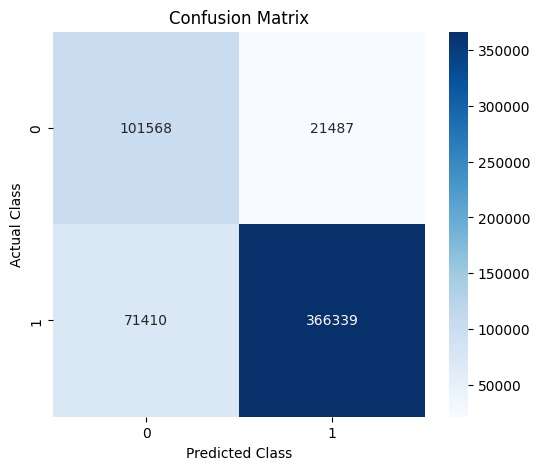

Confusion Matrix:
 [[101568  21487]
 [ 71410 366339]]


In [45]:
accuracy = accuracy_score(true_labels, pred)
print(f"Overall Accuracy: {accuracy:.4f}")
hf_auc = roc_auc_score(df['Sentiment'], pred_values)
print(f"AUC Score: {hf_auc:.4f}")


# B. Classification Report (Precision, Recall, F1-Score)
print("\nClassification Report (Key Metrics for Sentiment):")
# We use target names to clearly label the 0 and 1 classes
print(classification_report(true_labels, pred, target_names=['Negative (0)', 'Positive (1)']))

# C. Confusion Matrix (Essential Visualization)
cm = confusion_matrix(true_labels, pred)
print("confusion:\n", cm, "\n")
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',  xticklabels=logreg_model.classes_, yticklabels=logreg_model.classes_)
plt.title('Confusion Matrix')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

print("Confusion Matrix:\n", cm)

In [46]:
feature_names = vectorizer.get_feature_names_out()
coeffs = logreg_model.coef_[0]

top_positive_idx = coeffs.argsort()[-20:]
top_negative_idx = coeffs.argsort()[:20]

print("Top Positive Words:")
for i in top_positive_idx:
    print(feature_names[i], coeffs[i])

print("\nTop Negative Words:")
for i in top_negative_idx:
    print(feature_names[i], coeffs[i])

Top Positive Words:
happy 5.810414556012308
addicted 5.81920135072343
yum 6.175125220963983
thank 6.284102358369469
yummy 6.591038581982748
skeptical 6.811736608294164
awesome 6.93749594078687
pleased 7.0468639565326585
love 7.37850857536321
amazing 7.585142835094302
wonderful 8.152536757051692
pleasantly 8.197069504192404
loves 8.406713878493473
hooked 8.525478184312881
excellent 8.991613442251259
highly 9.428398635227042
best 9.893098431935396
perfect 9.97567202701064
delicious 10.885506776973143
great 11.236583062526845

Top Negative Words:
worst -11.37752889607545
disappointing -9.154131362390299
unfortunately -8.340246651988142
terrible -8.33587239584658
disappointment -8.015474638757695
disappointed -7.584468619021465
awful -7.436662084515663
ok -7.24641502315577
horrible -7.11274260419308
okay -6.9743491944282
threw -6.334364245339656
return -6.086950015767506
disgusting -6.052775498602958
hoping -5.783121699349568
weak -5.756297862293772
mediocre -5.684490700276912
stale -5.653

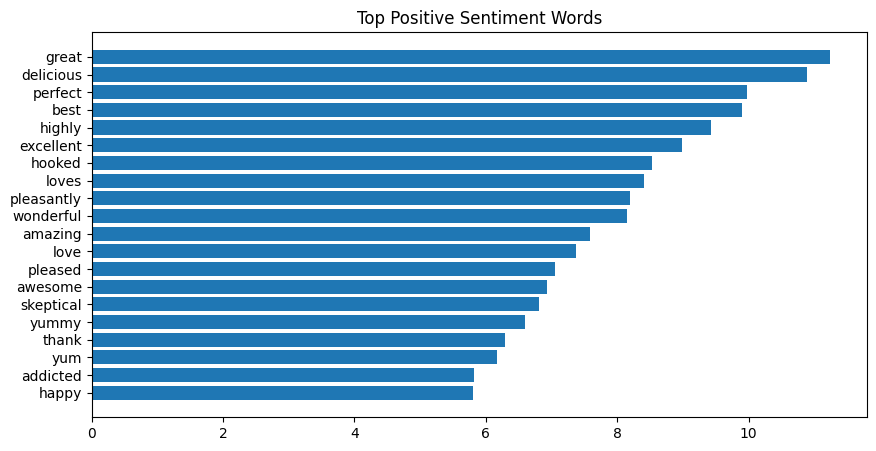

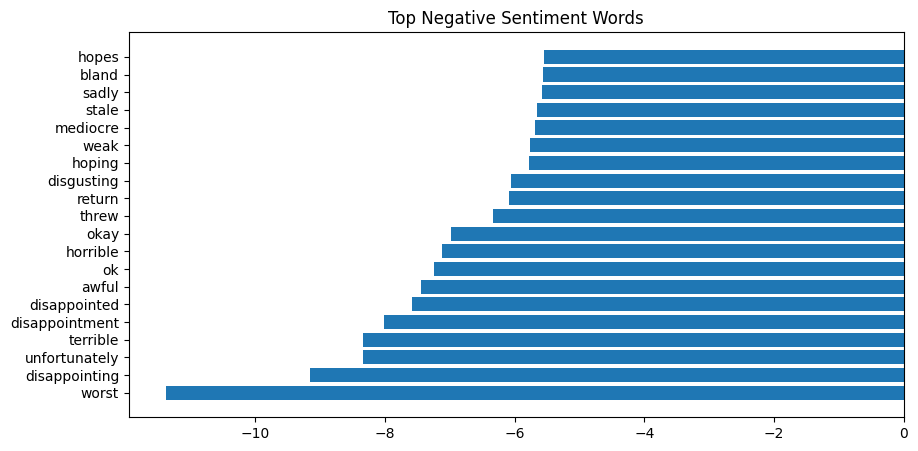

In [47]:
#bar chart for Top Positive and Negative Sentiment Words
pos_words = feature_names[top_positive_idx]
pos_values = coeffs[top_positive_idx]

neg_words = feature_names[top_negative_idx]
neg_values = coeffs[top_negative_idx]

plt.figure(figsize=(10,5))
plt.barh(pos_words, pos_values)
plt.title("Top Positive Sentiment Words")
plt.show()

plt.figure(figsize=(10,5))
plt.barh(neg_words, neg_values)
plt.title("Top Negative Sentiment Words")
plt.show()